In [4]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))
import importlib
import utils 
import utils.dataset
importlib.reload(utils)
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons
from utils.dna import Genes, create_template_from_genes
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt
from utils.dataset import get_raw_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler



In [9]:
GENESET = "medium"
FEATURES = "pca-combined-v1"
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
geneset_dataset = ProcessedDataset(DATA_DIR / f"{GENESET}_geneset_embeddings")
X, Y = get_raw_dataset(GENESET, FEATURES)
X_train, X_test, Y_train, Y_test, medium_images_train, medium_images_test = train_test_split(X, Y, geneset_dataset.alligned_images, test_size=0.1, random_state=42)
scaler_x = MinMaxScaler()
scaler_x.fit(X_train)
X_train_sc = scaler_x.transform(X_train)
X_test_sc = scaler_x.transform(X_test)

X_train = np.concatenate([X_train_sc])
Y_train = np.concatenate([Y_train])
train_images = np.concatenate([medium_images_train])

100%|██████████| 7/7 [00:00<00:00, 200.99it/s]


## Display genes on plane

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


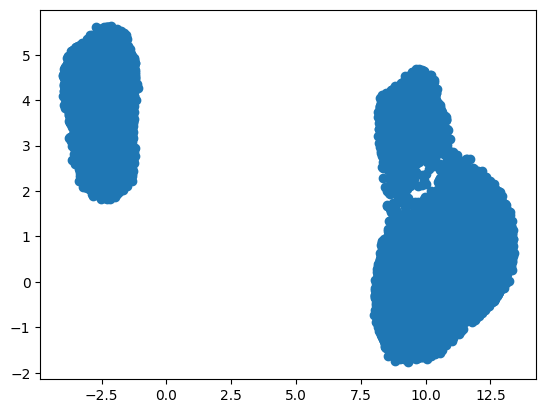

In [7]:
# run umap on X 
from umap import UMAP
u = UMAP(n_components=2)
X_train_umap = u.fit_transform(X_train)

plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1])
plt.show()

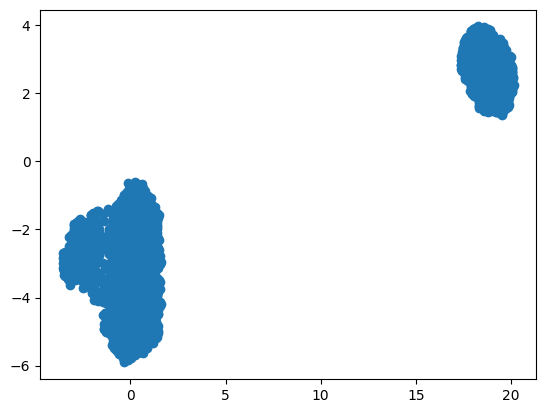

In [8]:
u = UMAP(n_components=2)
X_test_umap = u.fit_transform(X_test_sc)

plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1])
plt.show()

# Model

In [10]:
import importlib
import models.diffusion.ddpm as ddpm
import models.callbacks as callbacks
importlib.reload(ddpm)
importlib.reload(callbacks)
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
import torch 
from models.callbacks import MetricsCallback
from models.diffusion.ddpm import ConditionalDDPM, SimpleCondNet, ConditionalNetworkConfig
import torch.utils.data 
import wandb 

TRAIN = True
MODEL_CHECKPOINT = "/Users/czyjtu/dev/prompt2avatar/experiments/easy_geneset_embeddings/diff_model.ckpt"
WANDB_DIR = Path("../../checkpoints/diffusion") / GENESET
WANDB_DIR.mkdir(exist_ok=True, parents=True)


X_th = torch.tensor(X_train).float()
Y_th = torch.tensor(Y_train).float()

train_dataset = torch.utils.data.TensorDataset(X_th, Y_th)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test_sc).float(), torch.tensor(Y_test).float())
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

if TRAIN:
    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["diffusion", GENESET, FEATURES], group="diffusion" + GENESET, dir=WANDB_DIR
        ) as wandb_run:
        checkpoint_callback = ModelCheckpoint(
            monitor='val_loss',
            dirpath=WANDB_DIR / 'model_checkpoints',
            filename='best_model',
            save_top_k=1,
            mode='min'
        )
        wandb_logger = WandbLogger(project='prompt2avatar', entity="czyjtu", log_model="all", experiment=wandb_run)
        net_config = ConditionalNetworkConfig(
            input_dim=X_th.shape[1], 
            condition_dim=Y_th.shape[1], 
            condition_emb_dim=256, 
            inner_dim=[512, 512, 512, 512, 512], 
            condition_encoder_dim=[256, 256, 256, 256]
        )
        ddpm_len = ConditionalDDPM(net_config)
        # print(Y_ltr.shape())
        callback = MetricsCallback(
            torch.tensor(medium_images_test).float(),
            torch.tensor(X_test_sc).float(), 
            torch.tensor(Y_test).float(), 
            scaler_x
        )

        trainer = pl.Trainer(
            max_epochs=1000, 
            callbacks=[callback, checkpoint_callback], 
            logger=wandb_logger, 
            accelerator="mps"
            )
        trainer.fit(ddpm_len, train_dataloaders=train_loader, val_dataloaders=test_loader)
else:
    cond_ddpm = ConditionalDDPM.load_from_checkpoint(MODEL_CHECKPOINT)
    cond_ddpm = cond_ddpm.to("cpu")
    cond_ddpm.eval()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: czyjtu. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | net  | SimpleCondNet | 3.4 M  | train
-----------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.446    Total estimated model params size (MB)


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 999: 100%|██████████| 214/214 [00:09<00:00, 22.22it/s, v_num=3z7s, training_loss=0.045, val_loss=0.110, RMSE=0.195, Scaled RMSE=53.70, MAE=0.143, R2=-.496]    

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 214/214 [00:09<00:00, 22.21it/s, v_num=3z7s, training_loss=0.045, val_loss=0.110, RMSE=0.195, Scaled RMSE=53.70, MAE=0.143, R2=-.496]


MAE,█▄▄▄▃▃▃▃▂▃▂▂▂▂▂▂▂▃▂▂▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁
R2,▁▆▆▆▆▆▇▇▇▆▇▇▇▇▇▇▇▆▇▇██▇███████▇▇████████
RMSE,█▄▃▄▃▃▃▃▂▃▂▂▂▂▂▂▂▃▂▂▁▁▂▁▁▁▁▁▁▂▃▂▁▁▁▁▁▁▁▁
Scaled RMSE,█▃▃▃▃▃▃▂▂▃▂▂▂▂▂▂▂▃▁▂▁▁▂▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
training_loss,█▄▆▃▆▅▅▃▄▁▄▂▃▃▄▄▅▄▄▂▃▄▃▃▃▄▂▃▄▁▂▂▃▂▃▃▁▃▅▃
val_loss,█▅▃▄▃▄▃▅▃▃▂▃▄▃▃▂▃▂▂▃▂▂▃▂▁▁▃▂▁▂▂▁▂▁▂▂▂▁▁▂
MAE,0.14281
R2,-0.4962
RMSE,0.19522


In [11]:
ddpm_len.to("mps")
X_pred = callback.sample_model(ddpm_len).cpu().numpy()
pred_path = Path(f"../../experiments/{GENESET}_geneset_embeddings/predicted_dnas_diffusion")
save_predicitons(X_pred, scaler_x, pred_path, GENESET)

100%|██████████| 7/7 [00:00<00:00, 70.25it/s]


ValidationError: 1 validation error for Genes
face_detail_temple_def.temple_def
  Input should be greater than or equal to 0 [type=greater_than_equal, input_value=-2, input_type=int]
    For further information visit https://errors.pydantic.dev/2.7/v/greater_than_equal

# Ck true vs Ck pred face similarities

In [11]:
def get_cosine_similarity_matrix(X, X_pred):
    X = X / np.linalg.norm(X, axis=1)[:, None]
    X_pred = X_pred / np.linalg.norm(X_pred, axis=1)[:, None]
    return X @ X_pred.T

def display_random_pair(images, pred_images, i):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(images[i])
    ax[1].imshow(pred_images[i])
    plt.show()

DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
ROOT_DIR = Path(__name__).resolve().parents[2]
DATASET_NAME = 'easy_geneset_embeddings'
DATASET_DIR = DATA_DIR / DATASET_NAME
EXPERIMENT_DIR = ROOT_DIR / 'experiments' / DATASET_NAME
EXPERIMENT_DIR = Path("/Users/czyjtu/dev/prompt2avatar/experiments/easy_geneset_embeddings")
# GENESET = "easy"

pred_dataset = ProcessedDataset(EXPERIMENT_DIR / 'predicted_faces_diffusion_embeddings')
indicies_with_detected_faces = [int(p.split('_')[-1].split('.')[0]) for p in pred_dataset.paths]
test_images_with_faces = [test_images[i] for i in indicies_with_detected_faces]

100%|██████████| 1/1 [00:00<00:00, 402.06it/s]


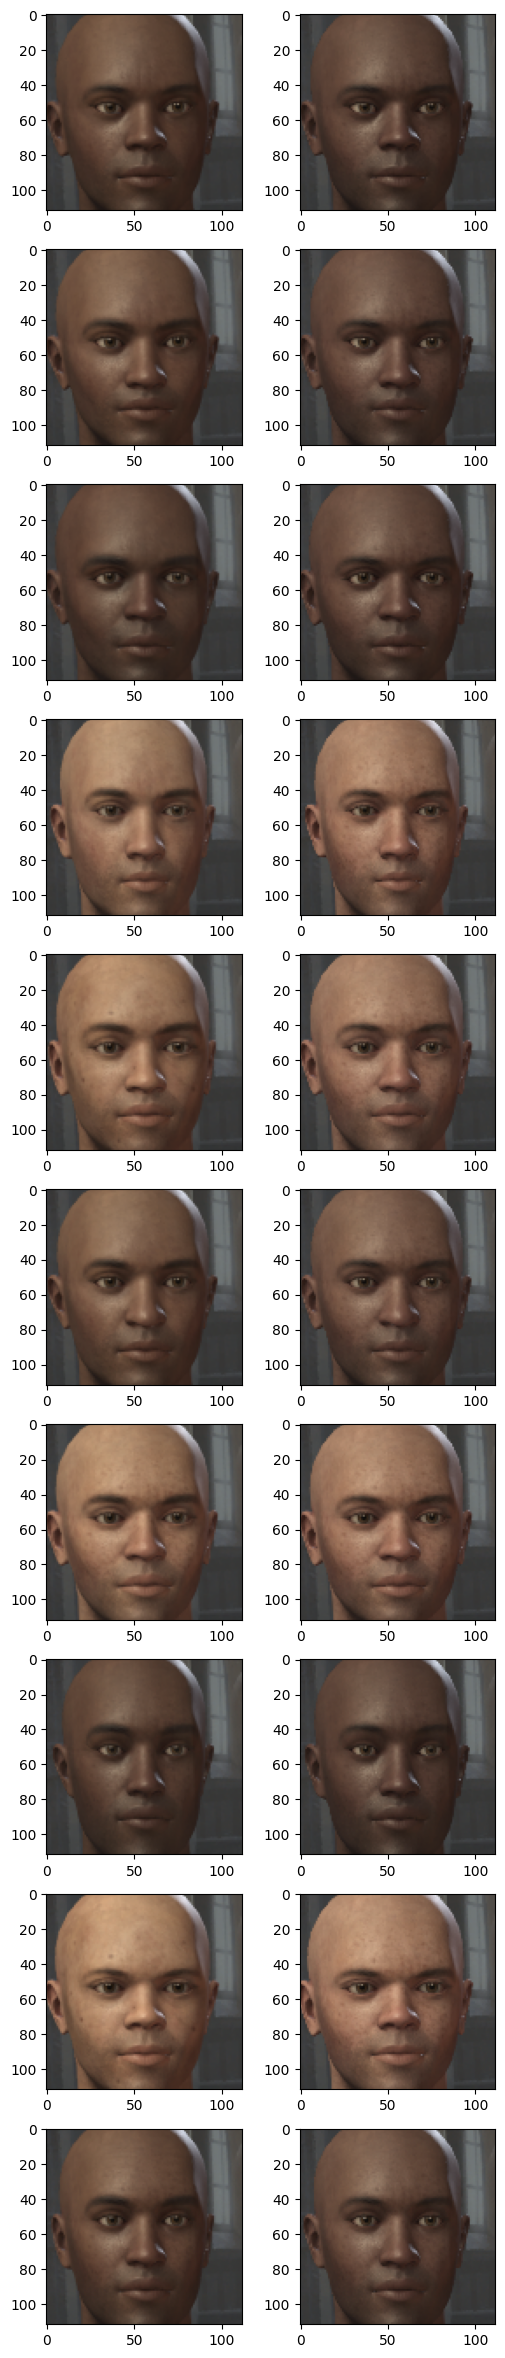

In [13]:
fig, axs = plt.subplots(10, 2, figsize=(6, 30))
for j, i in enumerate(range(100, 200, 10)):
    img = test_images_with_faces[i]
    pred_img = pred_dataset.alligned_images[i]
    axs[j, 0].imshow(img)
    axs[j, 1].imshow(pred_img)
plt.show()

# for i in range(100, 200, 10): display_random_pair(test_images_with_faces, pred_dataset.alligned_images, i)

In [10]:
# mean consine similarity between predicted and true embeddings
Y_pred_faces_features = pred_dataset.model2normalized_embeddings["arcface-r100"]
Y_real_faces_features = Y_test[indicies_with_detected_faces]
assert Y_pred_faces_features.shape == Y_real_faces_features.shape
cosine_sim = [x_true @ x_pred for x_true, x_pred in zip(Y_real_faces_features[1:], Y_pred_faces_features[1:])]
np.mean(cosine_sim)

0.8997438

# Real faces test 

In [4]:
from thirdparty.recognition.arcface_torch.backbones import get_model # source:https://github.com/deepinsight/insightface/tree/master
import insightface
from insightface.utils import face_align
import torch as th 
import torchvision.transforms as VT
import numpy as np 
import warnings 
from tqdm import tqdm 
from pathlib import Path 
import matplotlib.pyplot as plt
from PIL import Image

def display_image(img: np.ndarray):
    plt.imshow(img)
    plt.axis("off")
    plt.show()

class FaceDetector:
    def __init__(self):
        self.insight_face_app = insightface.app.FaceAnalysis(name="antelopev2", allowed_modules=["detection"])
        self.insight_face_app.prepare(ctx_id = 0, det_thresh = 0.1)

    def __call__(self, img: np.ndarray):
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        face = self.insight_face_app.get(img)[0]
        aimg = face_align.norm_crop(img, landmark=face.kps, image_size=112)
        return aimg
    
def allign_faces(images: np.ndarray, detector: FaceDetector, labels: list[str]) -> tuple[np.ndarray["X", float], np.ndarray["y", str]]:
    def handle_no_face_detected(img: np.ndarray, i: int) -> np.ndarray | None:
        try:
            return detector(img)
        except IndexError:
            warnings.warn(f"No face detected in image {i}")
            return None
    
    alligned_images = [handle_no_face_detected(img, i) for i, img in tqdm(list(enumerate(images)))]
    filtered_images, filtered_labels = zip(*[(img, label) for img, label in zip(alligned_images, labels) if img is not None])    
    return np.array(filtered_images), np.array(filtered_labels)


def _load_insightface_model(weights_path: str) -> th.nn.Module:
    resnet_version = weights_path.split("_")[-1].split(".")[0]
    model = get_model(resnet_version)
    model.load_state_dict(th.load(weights_path, map_location=th.device('cpu')))
    model = model.eval()
    return model

In [7]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
ROOT_DIR = Path(__name__).resolve().parents[2]
DATASET_NAME = 'easy_geneset_embeddings'
DATASET_DIR = DATA_DIR / DATASET_NAME
EXPERIMENT_DIR = ROOT_DIR / 'experiments' / DATASET_NAME

In [6]:
REAL_IMG_PATHS = DATA_DIR / 'ck_faces_dataset' 
real_images_paths = [
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/brad_pit/006_aee8d88b.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/dr_house/002_3299cc32.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/freddie_mercury/002_19e97a8c.jpg",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/kanye_west/image.png",
    "/Users/czyjtu/dev/prompt2avatar/data/real_faces_dataset/walter_white/002_7ff310e8.jpg"
]
    
real_images = [np.array(Image.open(p)) for p in real_images_paths]
detector = FaceDetector()
alligned_real_images, _ = allign_faces(real_images, detector, ["brad_pit", "dr_house", "freddie_mercury", "kanye_west", "walter_white"])

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/glintr100.onnx recognition
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


100%|██████████| 5/5 [00:00<00:00,  8.62it/s]


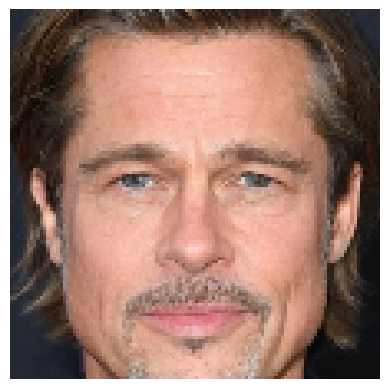

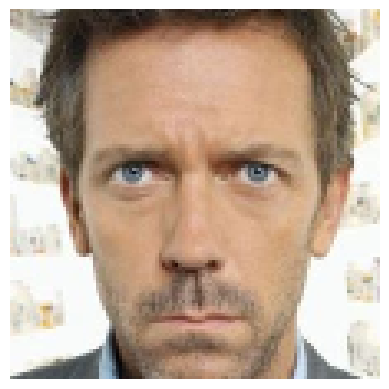

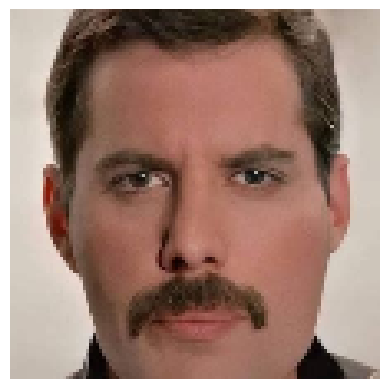

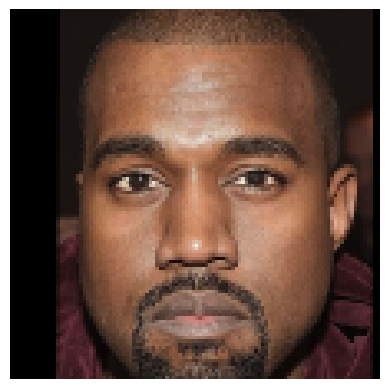

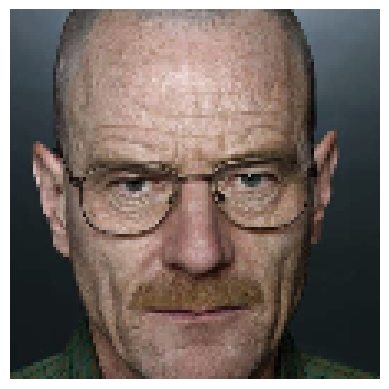

In [9]:
for img in alligned_real_images:
    display_image(img)

In [10]:
from utils.face_recognition import get_embeddings
from sklearn.preprocessing import normalize
RECOGNITION_MODEL_PATH = "/Users/czyjtu/dev/prompt2avatar/thirdparty/recognition/weights/arcface_r100.pth"
recognition_model = _load_insightface_model(RECOGNITION_MODEL_PATH)
real_image_embeddings = get_embeddings(alligned_real_images, recognition_model)
real_images_embeddings_normalized = normalize(real_image_embeddings)# / np.linalg.norm(real_image_embeddings, axis=1)[:, None]

100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


In [14]:
y = th.tensor(real_images_embeddings_normalized).float()
real_genes_pred = cond_ddpm.sample(num_samples=y.shape[0], return_intemediates=False, show_progress=True, Y=y).squeeze(0).detach().numpy()
# clip to 0 - 1 range 
# real_genes_pred_clipped = np.clip(real_genes_pred, 0, 1)
save_predicitons(real_genes_pred, scaler_x, EXPERIMENT_DIR / 'real_faces_sample_diffusion_embeddings', "easy")

100%|██████████| 1/1 [00:00<00:00, 83.04it/s]


In [15]:
real_genes_pred.min(), real_genes_pred.max()

(-0.097454466, 1.0181379)

## brad pit 
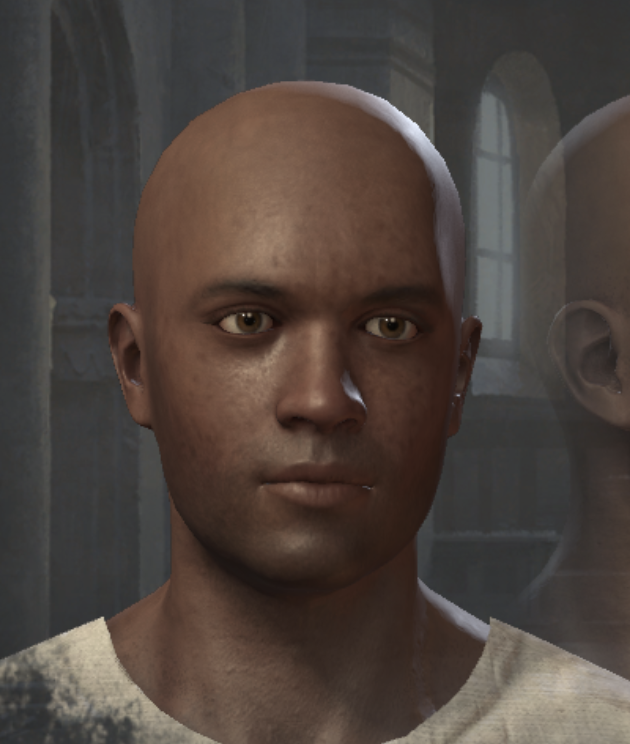

## dr house 
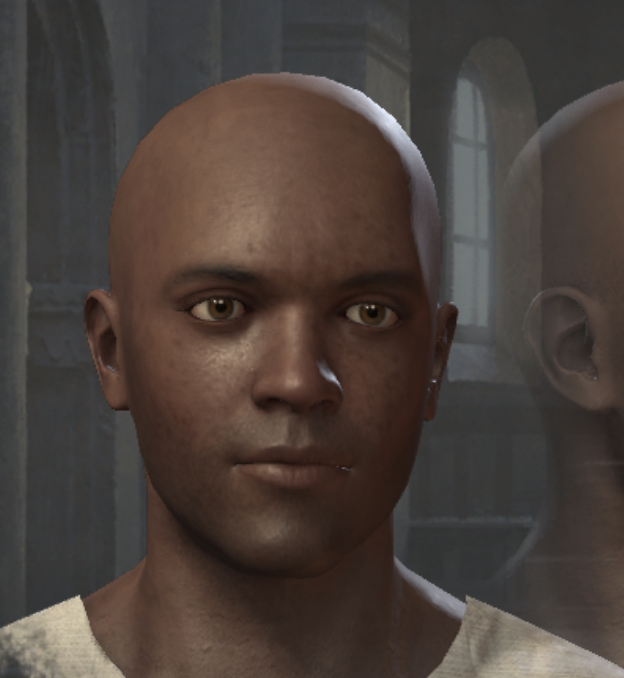

## freddie 
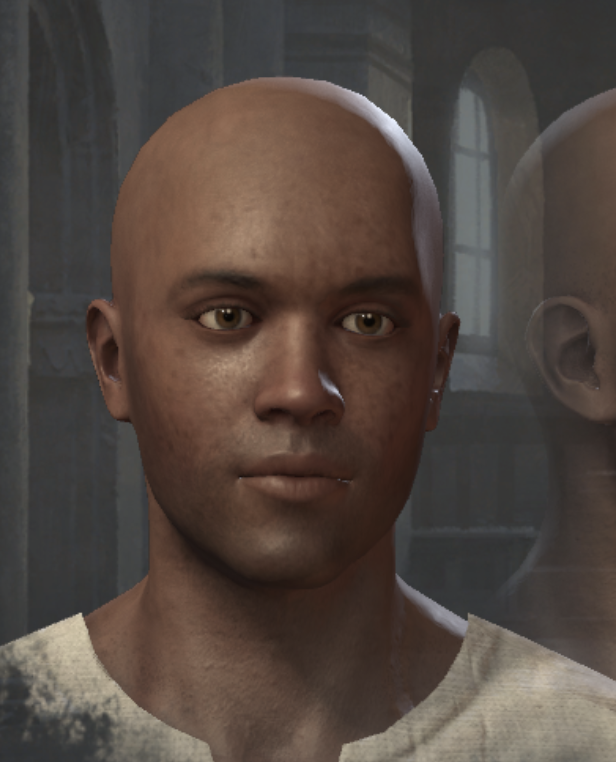

## kanye 
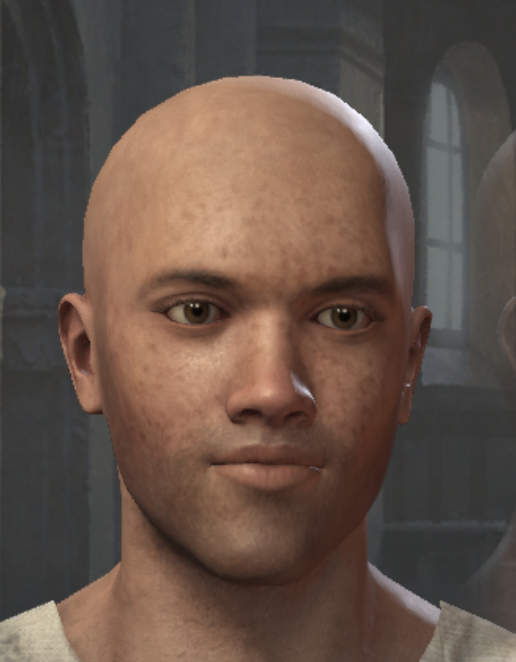

## walter 
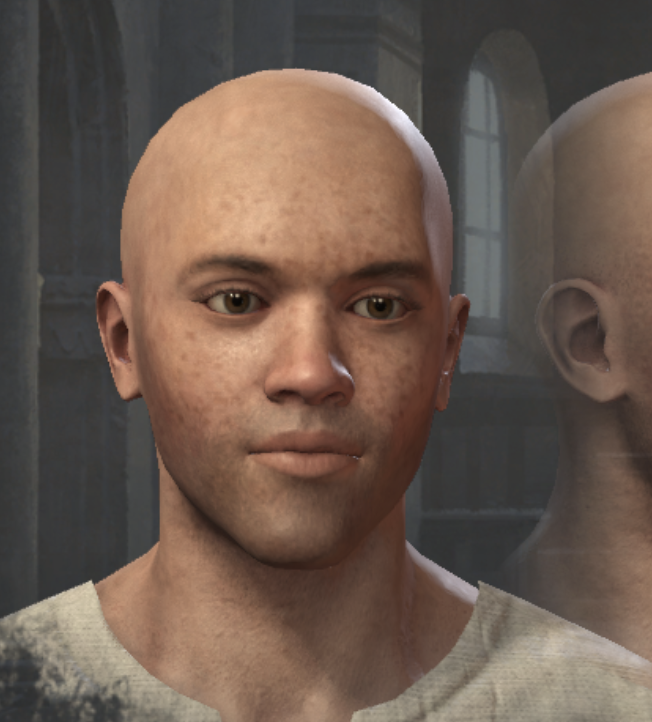